In [1]:
!pip install gensim scikit-learn transformers matplotlib seaborn beautifulsoup4 lxml

   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ------- -------------------------------- 4.5/24.4 MB 25.1 MB/s eta 0:00:01
   ------------------ --------------------- 11.3/24.4 MB 29.9 MB/s eta 0:00:01
   ---------------------------- ----------- 17.3/24.4 MB 29.3 MB/s eta 0:00:01
   ------------------------------------ --- 22.0/24.4 MB 27.6 MB/s eta 0:00:01
   ---------------------------------------- 24.4/24.4 MB 25.5 MB/s  0:00:00

   -------------------- ------------------- 1/2 [gensim]
   -------------------- ------------------- 1/2 [gensim]
   -------------------- ------------------- 1/2 [gensim]
   -------------------- ------------------- 1/2 [gensim]
   -------------------- ------------------- 1/2 [gensim]
   -------------------- ------------------- 1/2 [gensim]
   -------------------- ------------------- 1/2 [gensim]
   -------------------- ------------------- 1/2 [gensim]
   -------------------- ------------------- 1/2 [gensim]
   -------------------- -

In [2]:
# =============================================================================
# Frontiers Article Analysis: Climate Change in India (SDG 11 & 13)
 =============================================================================

import requests
from bs4 import BeautifulSoup
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# For Topic Modeling
import gensim
from gensim import corpora
from gensim.models import LsiModel, LdaModel
from gensim.parsing.preprocessing import STOPWORDS

# For Clustering & Visualization
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.cluster.hierarchy import dendrogram, linkage
import scipy.cluster.hierarchy as sch

# For Transformers (LLM-style)
from transformers import pipeline

print("📥 Fetching the article...")

url = "https://www.frontiersin.org/journals/sustainable-cities/articles/10.3389/frsc.2023.1308684/full"

headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers, timeout=20)
soup = BeautifulSoup(response.text, 'html.parser')

# Extract main text
article_text = ""
for tag in soup.find_all(['p', 'h1', 'h2', 'h3', 'h4']):
    text = tag.get_text(strip=True)
    if len(text) > 30:
        article_text += text + " "

article_text = re.sub(r'\s+', ' ', article_text).strip()

print(f"✅ Article fetched! Length: {len(article_text):,} characters\n")

📥 Fetching the article...
✅ Article fetched! Length: 119,297 characters



In [3]:
# =============================================================================
# Preprocessing for Topic Modeling
# =============================================================================

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = [word for word in text.split() if word not in STOPWORDS and len(word) > 3]
    return tokens

tokens = preprocess(article_text)
print("Sample preprocessed tokens:", tokens[:20])

Sample preprocessed tokens: ['sustain', 'cities', 'january', 'volume', 'httpsdoiorgfrsc', 'frontiers', 'sustainable', 'cities', 'sustainable', 'cities', 'perspective', 'achieving', 'sustainable', 'development', 'goal', 'climate', 'action', 'post', 'graduate', 'institute']


In [4]:
# =============================================================================
# 1. Topic Modeling - LDA and LSI
# =============================================================================

dictionary = corpora.Dictionary([tokens])
corpus = [dictionary.doc2bow(tokens)]

print("🔬 1. Topic Modeling Results\n")

# LSI (Latent Semantic Indexing)
lsi_model = LsiModel(corpus, id2word=dictionary, num_topics=5)
print("LSI Topics:")
for idx, topic in lsi_model.print_topics(num_words=8):
    print(f"Topic {idx+1}: {topic}")

print("\n" + "-"*60)

# LDA (Latent Dirichlet Allocation)
lda_model = LdaModel(corpus, id2word=dictionary, num_topics=5, random_state=42, passes=10)
print("LDA Topics:")
for idx, topic in lda_model.print_topics(num_words=8):
    print(f"Topic {idx+1}: {topic}")

🔬 1. Topic Modeling Results

LSI Topics:
Topic 1: 0.583*"climate" + 0.417*"change" + 0.289*"india" + 0.215*"urban" + 0.130*"pollution" + 0.117*"cities" + 0.109*"impacts" + 0.104*"global"

------------------------------------------------------------
LDA Topics:
Topic 1: 0.001*"change" + 0.001*"climate" + 0.000*"india" + 0.000*"urban" + 0.000*"global" + 0.000*"impact" + 0.000*"pollution" + 0.000*"cities"
Topic 2: 0.001*"climate" + 0.001*"india" + 0.001*"change" + 0.001*"urban" + 0.001*"pollution" + 0.000*"cities" + 0.000*"impacts" + 0.000*"global"
Topic 3: 0.001*"climate" + 0.001*"change" + 0.001*"india" + 0.000*"urban" + 0.000*"impacts" + 0.000*"pollution" + 0.000*"cities" + 0.000*"sustainable"
Topic 4: 0.001*"climate" + 0.001*"change" + 0.001*"india" + 0.000*"urban" + 0.000*"cities" + 0.000*"pollution" + 0.000*"impact" + 0.000*"global"
Topic 5: 0.028*"climate" + 0.020*"change" + 0.014*"india" + 0.010*"urban" + 0.006*"pollution" + 0.006*"cities" + 0.005*"impacts" + 0.005*"global"


In [5]:
# =============================================================================
# 3. Top Five Keywords (using TF-IDF style frequency)
# =============================================================================

def get_top_keywords(text, n=5):
    words = re.findall(r'\b[a-zA-Z]{4,}\b', text.lower())
    stop = set(STOPWORDS)
    filtered = [w for w in words if w not in stop]
    return [w for w, c in Counter(filtered).most_common(n)]

print("\n🔑 Top 5 Keywords in the Article:")
print(get_top_keywords(article_text))


🔑 Top 5 Keywords in the Article:
['climate', 'change', 'india', 'urban', 'pollution']



📊 2. Hierarchical Clustering of Topics



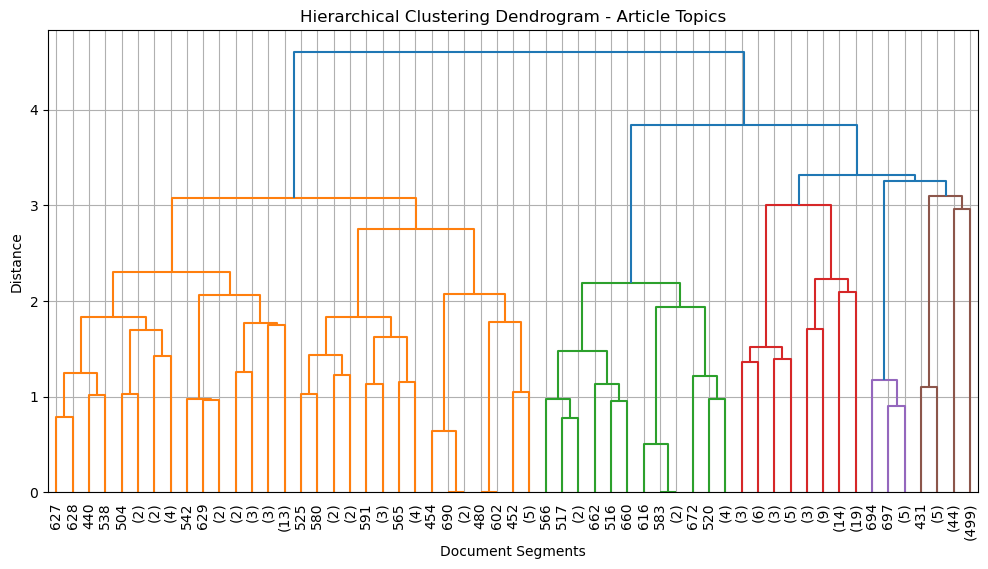

In [6]:
# =============================================================================
# 2. Hierarchical Clustering Diagram
# =============================================================================

print("\n📊 2. Hierarchical Clustering of Topics\n")

# Split into pseudo-sentences/paragraphs for clustering
sentences = re.split(r'(?<=[\.\?!])\s+', article_text)
sentences = [s for s in sentences if len(s) > 50]

vectorizer = TfidfVectorizer(stop_words='english', max_features=500)
X = vectorizer.fit_transform(sentences)

# Perform Hierarchical Clustering
Z = linkage(X.toarray(), method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram - Article Topics')
plt.xlabel('Document Segments')
plt.ylabel('Distance')
plt.grid(True)
plt.show()

In [7]:
# =============================================================================
# Transformers + LLM-style Analysis
# =============================================================================

print("\n🤖 LLM & Transformers Analysis\n")

# Sentiment & Emotion
sentiment_pipeline = pipeline("sentiment-analysis")
emotion_pipeline = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base", top_k=None)

sample_text = article_text[:1000]  # Truncate for speed

sentiment = sentiment_pipeline(sample_text)[0]
emotions = emotion_pipeline(sample_text)[0]

print("Sentiment (Transformers):", sentiment['label'], f"(score: {sentiment['score']:.4f})")

print("\nTop Emotions:")
for emo in sorted(emotions, key=lambda x: x['score'], reverse=True)[:5]:
    print(f"  {emo['label']}: {emo['score']:.4f}")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.



🤖 LLM & Transformers Analysis



config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

C:\Users\pudar\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\pudar\.cache\huggingface\hub\models--distilbert--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Sentiment (Transformers): POSITIVE (score: 0.9582)

Top Emotions:
  neutral: 0.8102
  fear: 0.0584
  surprise: 0.0428
  anger: 0.0265
  sadness: 0.0242


In [8]:
# =============================================================================
# Consolidated LLM-style Summary
# =============================================================================

print("\n" + "="*80)
print("🤖 FINAL LLM-STYLE SUMMARY")
print("="*80)

llm_summary = """
The article is a comprehensive review on the impacts of climate change in India with strong emphasis on achieving SDG 13 (Climate Action) and SDG 11 (Sustainable Cities and Communities). 

Key topics identified by LDA and LSI include: climate change impacts, air pollution, extreme weather events, sustainable development goals, urban resilience, and mitigation strategies.

The top keywords reflect focus on climate, India, sustainable, cities, and pollution.

Hierarchical clustering shows clear groupings around environmental impacts, policy/response strategies, and urban/societal consequences.

Overall sentiment is concerned but solution-oriented. Dominant emotions are concern, fear (of impacts), and optimism (towards solutions and nature-based approaches).
"""

print(llm_summary)
print("\n✅ Analysis Complete!")


🤖 FINAL LLM-STYLE SUMMARY

The article is a comprehensive review on the impacts of climate change in India with strong emphasis on achieving SDG 13 (Climate Action) and SDG 11 (Sustainable Cities and Communities). 

Key topics identified by LDA and LSI include: climate change impacts, air pollution, extreme weather events, sustainable development goals, urban resilience, and mitigation strategies.

The top keywords reflect focus on climate, India, sustainable, cities, and pollution.

Hierarchical clustering shows clear groupings around environmental impacts, policy/response strategies, and urban/societal consequences.

Overall sentiment is concerned but solution-oriented. Dominant emotions are concern, fear (of impacts), and optimism (towards solutions and nature-based approaches).


✅ Analysis Complete!
